In [20]:
%matplotlib widget

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import tqdm

from bscarlos.settings import RAW_DATA_FOLDER#, PROCESSED_DATA_FOLDER
from bscarlos.detector import ClusteringDetector

In [21]:
data_attributes = pd.read_csv(RAW_DATA_FOLDER / 'data_attributes.csv').set_index("unique_patient_id")
data_attributes.head(12)

,patient_id,start_sample,end_sample,sample_rate
unique_patient_id,,,,
Pat00,P1,4185435,4918141,200.0
Pat01,P2,12681997,13408848,200.0
Pat02,P3,39835,764218,200.0
Pat03,P4,10844009,11573448,200.0
Pat04,P5,901647,1624579,200.0
Pat05,P6,1498558,2228672,200.0
Pat06,P7,26427086,28254747,500.0
Pat07,P8,5288360,7117935,500.0
Pat08,P9,10352423,12177350,500.0


Check `sample_rate` frequency for patient 11

In [33]:
print(data_attributes['sample_rate'].iloc[12])

200.0


### Load Data Files

In [22]:
data_files = sorted(list(RAW_DATA_FOLDER.glob('*.parquet')))

### Create `patient_data` dictionary
store all relavant information for BSUPP Algorithm

In [23]:
patient11_data = pd.read_parquet(data_files[11])
patient11_data.head()

,0,1,2,3,4,5,ground_truth
0,-2.125208e-14,-8.035298e-17,2.954411e-16,-2.061422e-14,3.581822e-17,-6.138506e-17,0.0
1,-6.733956e-13,-2.757012e-15,1.038735e-14,-6.504592e-13,1.148263e-15,-2.187759e-15,0.0
2,-1.054640e-11,-4.713928e-14,1.821454e-13,-1.013861e-11,1.828590e-14,-3.884024e-14,0.0
3,-1.088928e-10,-5.362328e-13,2.126695e-12,-1.041058e-10,1.931936e-13,-4.585406e-13,0.0
4,-8.340102e-10,-4.571918e-12,1.862342e-11,-7.922061e-10,1.526194e-12,-4.054721e-12,0.0


### Create Learning and Testing Data
Seprating data based on:
- Learning period == First 15min Window
- Testing period >= 15min

In [24]:
fs = 200
learning_period_s = 60*15 
data_learning = patient11_data.iloc[0:fs*learning_period_s]
data_learning.index = data_learning.index*pd.Timedelta(1/fs, 's')
data_testing = patient11_data.iloc[fs*learning_period_s:]
data_testing.index = data_testing.index*pd.Timedelta(1/fs, 's')

In [25]:
def plot_eeg(df):
    t_s = (df.index/pd.Timedelta(1, 's')).to_numpy()

    plt.figure()

    for i, col in enumerate(df):

        scale = 1
        if str(col) not in {'0', '1', '2', '3', '4', '5'}:
            scale = 50

        x = df[col].to_numpy()
        plt.plot(t_s, scale*x+100*i, label=col)

    plt.xlabel('time [s]')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4)
    plt.tight_layout()

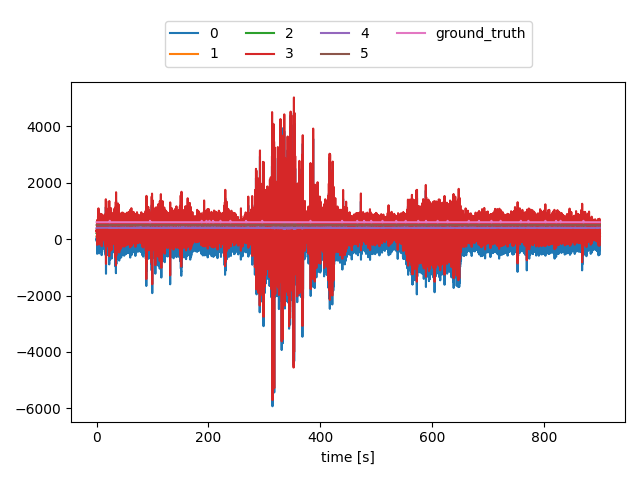

In [26]:
plot_eeg(data_learning)

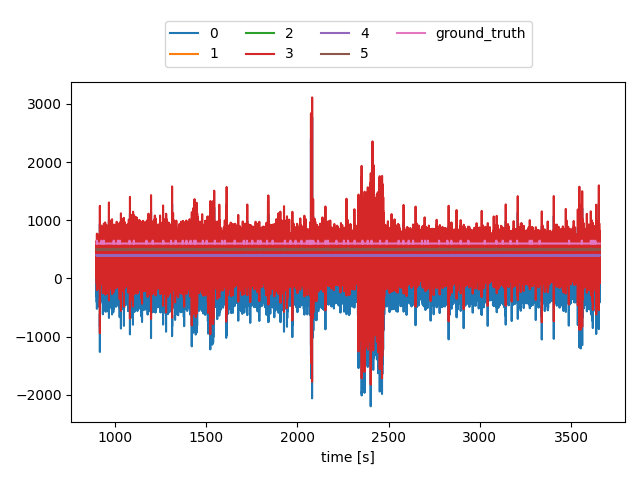

In [27]:
plot_eeg(data_testing)

### Create EEG-only Data 
Dropping 'ground_truth' column from learning and testing datasets


In [35]:
eeg_cols = [str(i) for i in range(6)]

In [36]:
# separate eeg
eeg_learning = data_learning[eeg_cols]
eeg_learning.head()

,0,1,2,3,4,5
0 days 00:00:00,-2.125208e-14,-8.035298e-17,2.954411e-16,-2.061422e-14,3.581822e-17,-6.138506e-17
0 days 00:00:00.005000,-6.733956e-13,-2.757012e-15,1.038735e-14,-6.504592e-13,1.148263e-15,-2.187759e-15
0 days 00:00:00.010000,-1.054640e-11,-4.713928e-14,1.821454e-13,-1.013861e-11,1.828590e-14,-3.884024e-14
0 days 00:00:00.015000,-1.088928e-10,-5.362328e-13,2.126695e-12,-1.041058e-10,1.931936e-13,-4.585406e-13
0 days 00:00:00.020000,-8.340102e-10,-4.571918e-12,1.862342e-11,-7.922061e-10,1.526194e-12,-4.054721e-12


### Apply Clustering Detector on patient 11

In [37]:
detector = ClusteringDetector()
detector.fit(eeg_learning)

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [38]:
def combine_windows_with_labels(windows, labels):
    label_datasets = []
    for label, window in zip(labels, windows):
        temp = pd.DataFrame(index=window.index, data={})
        temp['label'] = label
        label_datasets.append(temp)
    return pd.concat(label_datasets)

In [39]:
labels_frame = combine_windows_with_labels(detector.get_windows(eeg_learning), detector.labels_)
data_learning_labeled = data_learning.copy()
data_learning_labeled['label'] = labels_frame['label']

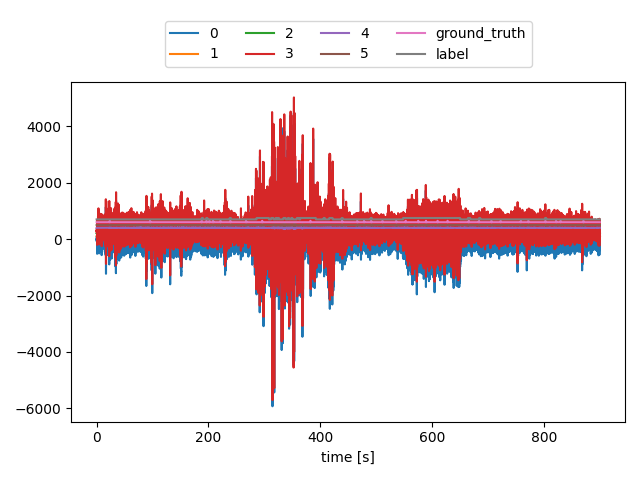

In [40]:
plot_eeg(data_learning_labeled)

####  Make predictions 

In [41]:
data_testing_cropped = data_testing.iloc[0:60*15*fs, :]

In [42]:
eeg_testing = data_testing_cropped[eeg_cols]
eeg_testing.head()

,0,1,2,3,4,5
0 days 00:15:00,-302.516671,1.388489,-1.809780,-268.759604,1.868850,0.687551
0 days 00:15:00.005000,-248.518218,1.373936,-1.786901,-216.958541,1.449068,1.549154
0 days 00:15:00.010000,-171.587680,1.183795,-1.739043,-145.510272,0.911667,2.357755
0 days 00:15:00.015000,-77.396480,0.851699,-1.673508,-59.776094,0.316204,3.030592
0 days 00:15:00.020000,26.012163,0.431541,-1.594963,32.910505,-0.271281,3.506238


In [43]:
labels_predicted = detector.predict(eeg_testing)

In [44]:
labels_frame_training = combine_windows_with_labels(detector.get_windows(eeg_testing), labels_predicted)
data_testing_cropped_labeled = data_testing_cropped.copy()
data_testing_cropped_labeled['label'] = labels_frame_training['label']

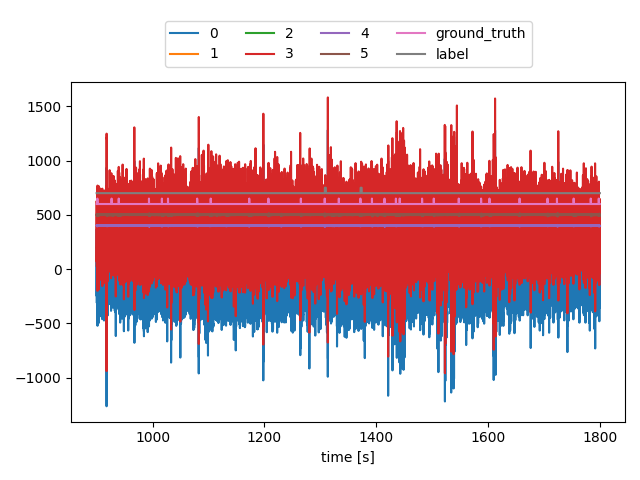

In [45]:
plot_eeg(data_testing_cropped_labeled)

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def plot_eeg(df):
    t_s = (df.index/pd.Timedelta(1, 's')).to_numpy()

    fig, ax = plt.subplots(figsize=(10, 6))

    lines = []
    for i, col in enumerate(df):
        scale = 1
        if str(col) not in {'0', '1', '2', '3', '4', '5'}:
            scale = 50

        x = df[col].to_numpy()
        line, = ax.plot(t_s, scale*x+100*i, label=col)
        lines.append(line)

    ax.set_xlabel('time [s]')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4)

    # Add interactive scrollbar
    scroll = widgets.IntSlider(min=0, max=t_s[-1], step=1, description='Time (s):')
    widgets.jslink((scroll, 'value'), (ax, 'xlim'))
    display(scroll)

    # Add ability to toggle visibility of individual channels
    checkboxes = [widgets.Checkbox(value=True, description=col) for col in df.columns]
    for checkbox, line in zip(checkboxes, lines):
        widgets.jslink((checkbox, 'value'), (line, 'visible'))
    display(widgets.HBox(checkboxes))

    plt.tight_layout()
    plt.show()

### Calculate AUROC 

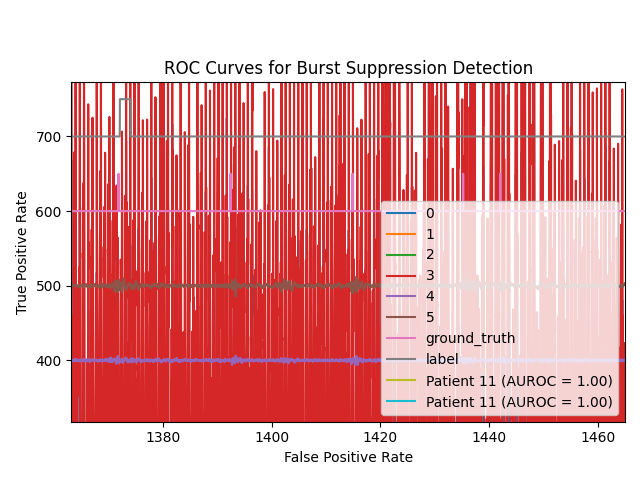

In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
# calculate auroc for patient 11

true_labels = data_testing_cropped_labeled['label']  # ground truth labels
scores = data_testing_cropped_labeled['label']  # predicted labels   

fpr, tpr, _ = roc_curve(true_labels, scores)
auroc_scores = roc_auc_score(true_labels, scores)

patient_id = 11

plt.plot(fpr, tpr, label=f'Patient 11 (AUROC = {auroc_scores:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal dashed line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Burst Suppression Detection')
plt.legend(loc="lower right")
plt.show()
                                                               

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for patient_id, results in results_for_analysis.items():
    true_labels = results['labels']
    scores = results['predictions']
    
    fpr, tpr, _ = roc_curve(true_labels, scores)
    plt.plot(fpr, tpr, label=f'Patient {patient_id} (AUROC = {auroc_scores[patient_id]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal dashed line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Burst Suppression Detection')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# data_testing

to do: 
- save calculated predictions as parquet file
- plot results for a couple of patients from patient_data dictionary
- widen ground truth by 2s
- compare results in all patients:
    - check in which direction to fill bfill() method
    -   extend ground truth by fill forward ffill() method
    -   visually inspect to see which direction
- calculate the difference between (.labels_ - ground_truth)=False positves and (ground_truth - labels_)=False negatives
- research literature to see validation methods; send to Jenny
- run rf on all patients
- compare clusteringdector to rf